# Evaluación del Modelo Final

Análisis detallado de errores: ¿qué tipo de eventos generan más falsos positivos?

In [6]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.loader import load_bgl_logs
from src.data.preprocessor import add_severity_score, train_test_split_temporal
from src.features.engineering import load_features
from src.models.detector import AnomalyDetector

plt.rcParams['figure.dpi'] = 120

MODEL_PATH = Path('../models/saved/lof_v1.joblib')
FEATURES_PATH = Path('../data/processed/features_train.parquet')

In [7]:
detector = AnomalyDetector.load(MODEL_PATH)
df_feat = load_features(FEATURES_PATH)

feature_cols = [c for c in df_feat.columns if c not in {'timestamp', 'node', 'is_anomaly'}]
_, test_df = train_test_split_temporal(df_feat, test_fraction=0.2)

X_test = test_df[feature_cols].fillna(0).values
y_test = test_df['is_anomaly'].values
y_pred = detector.predict(X_test)
scores = detector.score_samples(X_test)

test_df = test_df.copy()
test_df['y_pred'] = y_pred
test_df['anomaly_score'] = scores

## 1. Matriz de confusión

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('=== Matriz de Confusión ===')
print(f'              Pred Normal  Pred Anomalía')
print(f'Real Normal      {tn:>8,}       {fp:>8,}  ← Falsos Positivos')
print(f'Real Anomalía    {fn:>8,}       {tp:>8,}  ← Verdaderos Positivos')
print()
print(f'Precision: {tp/(tp+fp):.4f}  (de las alertas, cuántas son reales)')
print(f'Recall:    {tp/(tp+fn):.4f}  (de las anomalías reales, cuántas detectamos)')

=== Matriz de Confusión ===
              Pred Normal  Pred Anomalía
Real Normal         1,294          5,980  ← Falsos Positivos
Real Anomalía       1,934         70,792  ← Verdaderos Positivos

Precision: 0.9221  (de las alertas, cuántas son reales)
Recall:    0.9734  (de las anomalías reales, cuántas detectamos)


## 2. Análisis de Falsos Positivos

In [9]:
df_raw = load_bgl_logs(Path('../data/raw/BGL.log'), nrows=500_000)
df_raw = add_severity_score(df_raw)
_, df_test_raw = train_test_split_temporal(df_raw)
df_test_raw = df_test_raw.reset_index(drop=True).iloc[:len(test_df)].copy()
df_test_raw['y_pred'] = y_pred
df_test_raw['anomaly_score'] = scores

false_positives = df_test_raw[(df_test_raw['y_pred'] == 1) & (~df_test_raw['is_anomaly'])]
print(f'Total falsos positivos: {len(false_positives):,}')

print('\nFP por nivel de log:')
print(false_positives['level'].value_counts())

print('\nFP por componente (top 10):')
print(false_positives['component'].value_counts().head(10))

Total falsos positivos: 57,369

FP por nivel de log:
level
FATAL      44928
INFO       12441
ERROR          0
SEVERE         0
WARNING        0
Name: count, dtype: int64

FP por componente (top 10):
component
KERNEL       57201
APP            167
LINKCARD         1
CMCS             0
DISCOVERY        0
HARDWARE         0
MMCS             0
Name: count, dtype: int64


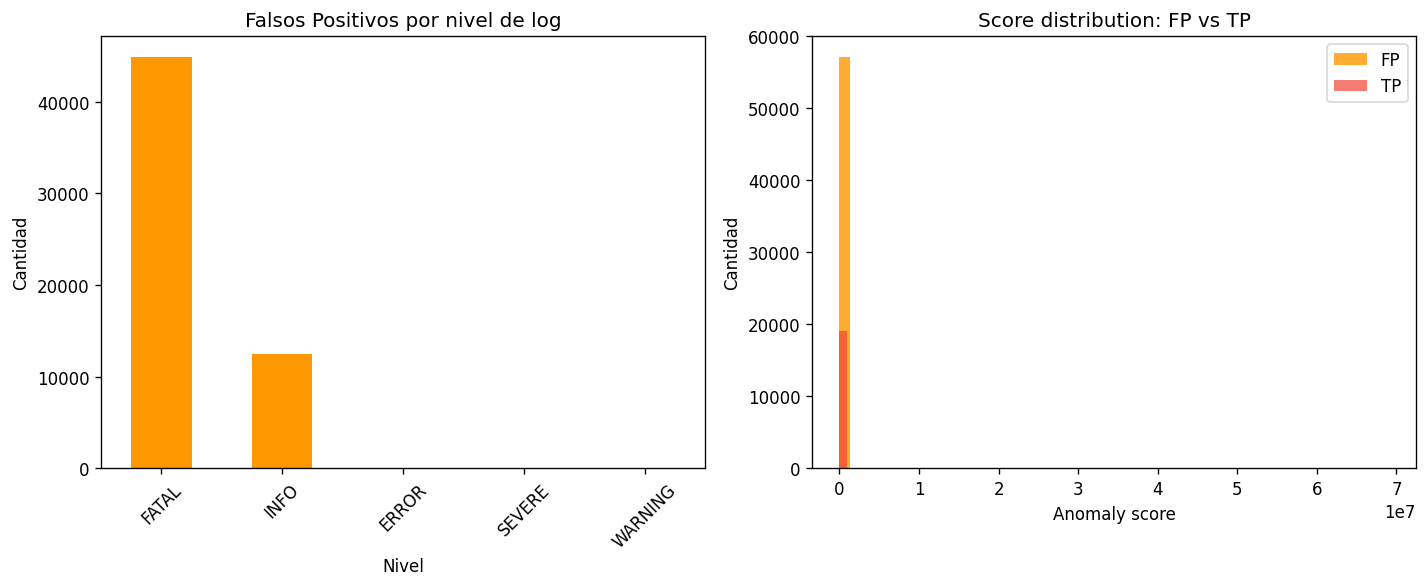

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fp_levels = false_positives['level'].value_counts().head(8)
fp_levels.plot(kind='bar', ax=ax1, color='#FF9800')
ax1.set_title('Falsos Positivos por nivel de log')
ax1.set_xlabel('Nivel')
ax1.set_ylabel('Cantidad')
ax1.tick_params(axis='x', rotation=45)

ax2.hist(false_positives['anomaly_score'], bins=50, color='#FF9800', alpha=0.8, label='FP')
true_positives = df_test_raw[(df_test_raw['y_pred'] == 1) & (df_test_raw['is_anomaly'])]
ax2.hist(true_positives['anomaly_score'], bins=50, color='#F44336', alpha=0.7, label='TP')
ax2.set_xlabel('Anomaly score')
ax2.set_ylabel('Cantidad')
ax2.set_title('Score distribution: FP vs TP')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_false_positives.png', dpi=150)
plt.show()

## 3. Ejemplos de anomalías detectadas (score más alto)

In [11]:
top_anomalies = df_test_raw[df_test_raw['y_pred'] == 1].nlargest(10, 'anomaly_score')
pd.set_option('display.max_colwidth', 80)
top_anomalies[['timestamp', 'node', 'level', 'component', 'content', 'anomaly_score', 'is_anomaly']]

,timestamp,node,level,component,content,anomaly_score,is_anomaly
52486,2005-06-14 09:18:20.983666,R02-M0-N3-C:J06-U01,FATAL,KERNEL,instruction address: 0x00004ed8,69004232.0,False
52487,2005-06-14 09:18:21.009991,R02-M0-N3-C:J04-U11,FATAL,KERNEL,instruction address: 0x00004ed8,69004232.0,False
52483,2005-06-14 09:18:20.905180,R02-M0-N3-C:J12-U01,FATAL,KERNEL,instruction address: 0x00004ed8,46454992.0,False
40967,2005-06-14 09:11:59.496586,R16-M0-N8-C:J04-U11,FATAL,KERNEL,data storage interrupt,45680456.0,True
40969,2005-06-14 09:11:59.552628,R16-M0-N8-C:J02-U11,FATAL,KERNEL,data storage interrupt,45680456.0,True
40970,2005-06-14 09:11:59.580852,R16-M1-N4-C:J09-U11,FATAL,KERNEL,data storage interrupt,45680456.0,True
40971,2005-06-14 09:11:59.609041,R16-M1-N4-C:J15-U11,FATAL,KERNEL,data storage interrupt,45680456.0,True
40972,2005-06-14 09:11:59.641721,R16-M1-N4-C:J11-U11,FATAL,KERNEL,data storage interrupt,45680456.0,True
40974,2005-06-14 09:11:59.740566,R16-M1-N4-C:J17-U11,FATAL,KERNEL,data storage interrupt,45680456.0,True
40976,2005-06-14 09:11:59.798717,R16-M1-N4-C:J03-U01,FATAL,KERNEL,data storage interrupt,45680456.0,True
